# DATA ANALYSIS

# Lodaing dataset

In [1]:
# ==== IMPORSTS & SETTINGS ====
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

# ==== FUNCTION ====
def load_csv_to_df(csv_path, sep=";"):
    try:
        df = pd.read_csv(csv_path, encoding="utf-8", sep=sep)
        print(f"Successfully loaded CSV from {csv_path}")
        print(f"DataFrame shape: {df.shape}")
        print(f"DataFrame columns: {df.columns.tolist()}\n")
        return df
    except Exception as e:
        print(f"Error loading CSV from {csv_path}: {e}")
        return None

def load_parquet_to_df(parquet_path, na=False):
    try:
        df = pd.read_parquet(parquet_path)
        print(f"Successfully loaded Parquet from {parquet_path}")
        print(f"DataFrame shape: {df.shape}")
        if na:
            print(f"DataFrame N/A counts:\n{df.isna().sum()}\n")
        print(f"DataFrame columns: {df.columns.tolist()}\n")
        return df
    except Exception as e:
        print(f"Error loading Parquet from {parquet_path}: {e}")
        return None

# ==== DEFINE PATHS ====
data_path = "../Data/gcp_order/dtu_findit/extraction_and_processing/"

# ==== DEFINE FILES ====
file1 = "thesis_meta_added_equations_to_olivers_26032026.parquet"
file2 = "thesis_meta_added_linguistics_to_olivers_26032026.parquet"
file3 = "thesis_meta_added_supervisors_26032026.parquet"
file4 = "thesis_meta_all_metrics_except_grade_27032026.parquet"
file5 = "thesis_meta_all_metrics_except_grade_filtered_27032026.parquet"

# ==== LOAD DATAFRAMES ====
#print("df1:")
#df1 = load_parquet_to_df(data_path + file1)
#print("df2:")
#df2 = load_parquet_to_df(data_path + file2)
#print("df3:")
#df3 = load_parquet_to_df(data_path + file3)
df_all = load_parquet_to_df(data_path + file4)
df_filtered = load_parquet_to_df(data_path + file5)

# ==== DROP NA COLUMNS ====
df_all_noNA = df_all.dropna(axis=1, how="all")
print(f"df_all_noNA shape: {df_all_noNA.shape}")
print(f"df_all_noNA columns: {df_all_noNA.columns.tolist()}\n")
df_filtered_noNA = df_filtered.dropna(axis=1, how="all")
print(f"df_filtered_noNA shape: {df_filtered_noNA.shape}")
print(f"df_filtered_noNA columns: {df_filtered_noNA.columns.tolist()}\n")

# ==== COLUMNS TO DROP ====
drop_columns = [
    "access_ss",
    "Affiliations",
    "collection_facet",
    "format",
    "fulltext_availability_facet",
    "ISBN",
    "Journal Page",
    "isolanguage_facet",
    "Publisher",
    "Source",
    "source_all_ss",
    "match_trigger",
    "equation_pipeline_version",
    "pdf_file_analysis",
    "num_tot_pages_analysis",
    "num_cont_pages_analysis",
    "num_words_full_analysis",
    "num_words_cont_analysis",
    "abstract_ts_analysis",
    "Author_analysis",
    "Publication Year_analysis",
    "primary_member_id_s_analysis",
    "Title_analysis",
    ]

# ==== DROP COLUMNS ====
df_all_noNA_clean = df_all_noNA.drop(columns=drop_columns, errors="ignore")
print(f"df_all_noNA_clean shape: {df_all_noNA_clean.shape}")
print(f"df_all_noNA_clean columns: {df_all_noNA_clean.columns.tolist()}\n")
df_filtered_noNA_clean = df_filtered_noNA.drop(columns=drop_columns, errors="ignore")
print(f"df_filtered_noNA_clean shape: {df_filtered_noNA_clean.shape}")
print(f"df_filtered_noNA_clean columns: {df_filtered_noNA_clean.columns.tolist()}\n")

# ==== LOCK DATAFRAMES FOR ANALYSIS ====
print("Final DataFrames for Analysis:")
df_all_final = df_all_noNA_clean.copy()
print(f"df_all_final shape: {df_all_final.shape}")
df_filtered_final = df_filtered_noNA_clean.copy()
print(f"df_filtered_final shape: {df_filtered_final.shape}")

Successfully loaded Parquet from ../Data/gcp_order/dtu_findit/extraction_and_processing/thesis_meta_all_metrics_except_grade_27032026.parquet
DataFrame shape: (19690, 76)
DataFrame columns: ['abstract_ts', 'access_ss', 'Affiliations', 'Timestamp', 'Author', 'citation_count_i', 'ID', 'dtu_library_collection_facet', 'collection_facet', 'Publication Year', 'Conference', 'DOI', 'Editor', 'embargo_ssf', 'format', 'fulltext_availability_facet', 'has_openaccess_fulltext_b', 'holdings_ssf', 'ISBN', 'Journal Issue', 'journal_issue_tsort', 'journal_oa_model_ss', 'Journal Page', 'journal_page_start_tsort', 'Journal Title', 'journal_title_facet', 'toc_key_s', 'Journal Volume', 'journal_vol_tsort', 'keywords_ts', 'keywords_facet', 'keywords_normalized', 'isolanguage_facet', 'member_id_ss', 'ORCID', 'primary_member_id_s', 'Publisher', 'Source', 'source_all_ss', 'Title', 'MASTER THESIS TITLE', 'BY', 'SUPERVISED BY', 'YEAR', 'PUBLISHER', 'TYPES', 'pdf_file', 'num_tot_pages', 'num_cont_pages', 'num_wor

## Exclude rows where Publication Year is 2026?

In [2]:
choice = input("Excluded rows with Publication Year == 2026? (Y/n): ").strip().lower()

if choice == "n":
    print("Keeping rows with Publication Year == 2026.")
else:
    # drop rows that has "Publication Year" == 2026
    print("df_all_final")
    df_all_final = df_all_final[df_all_final["Publication Year"] != 2026]
    excluded_rows_all = pd.to_numeric(df_all_noNA_clean["Publication Year"], errors="coerce").eq(2026).sum()
    print(f"Number of rows dropped with Publication Year == 2026: {excluded_rows_all}")
    print(f"df_all_final shape after dropping rows with Publication Year == 2026: {df_all_final.shape}\n")
    
    print("df_filtered_final")
    df_filtered_final = df_filtered_final[df_filtered_final["Publication Year"] != 2026]
    excluded_rows_filtered = pd.to_numeric(df_filtered_noNA_clean["Publication Year"], errors="coerce").eq(2026).sum()
    print(f"Number of rows dropped with Publication Year == 2026: {excluded_rows_filtered}")
    print(f"df_filtered_final shape after dropping rows with Publication Year == 2026: {df_filtered_final.shape}")


df_all_final
Number of rows dropped with Publication Year == 2026: 6
df_all_final shape after dropping rows with Publication Year == 2026: (19684, 32)

df_filtered_final
Number of rows dropped with Publication Year == 2026: 3
df_filtered_final shape after dropping rows with Publication Year == 2026: (6251, 45)


The DataFrames to use are:
- `df_all_final`
- `df_filtered_final`

# General stats

## For the **filtered** dataset: `df_filtered_final`

--- Thesis Count by Department ---
Department_new
DTU Compute                   1190
DTU Construct                 1017
DTU Electro                    681
DTU Management                 633
DTU Wind                       531
DTU Health Tech                454
DTU Sustain                    430
DTU Bioengineering             243
DTU Space                      232
DTU Chemical Engineering       189
DTU Food                       159
DTU Physics                    123
DTU Aqua                       111
DTU Energy                     106
DTU Chemistry                   91
DTU Engineering Technology      25
Name: count, dtype: int64


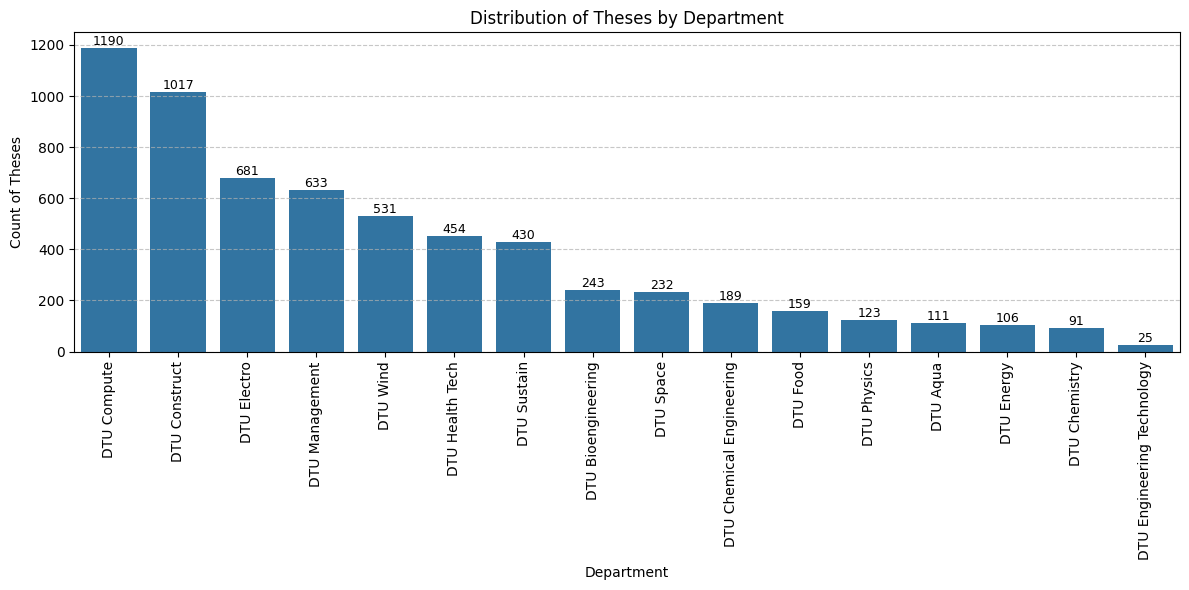

In [3]:
# print table of df department_new count of each unique
dept_counts = df_filtered_final['Department_new'].value_counts()
print("--- Thesis Count by Department ---")
print(dept_counts)

# plot df department_new count of each unique + show count on bars
plt.figure(figsize=(12, 6))
ax = sns.countplot(
    data=df_filtered_final,
    x='Department_new',
    order=df_filtered_final['Department_new'].value_counts().index
)

# add count labels at the end (top) of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=0, fontsize=9)

plt.xticks(rotation=90)
plt.title('Distribution of Theses by Department')
plt.xlabel('Department')
plt.ylabel('Count of Theses')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Serching for trends around 2023 (realaese of ChatGPT)*
*This section has been generated and notes written by Gemini.

Link to chat used:
https://gemini.google.com/share/9f9e455c59c9

In [4]:
# Using the filtered dataset
df = df_filtered_final.copy()

## 1. General Correlation with Publication Year
This plot provides a high-level overview of which thesis metrics are most strongly associated with the passage of time.

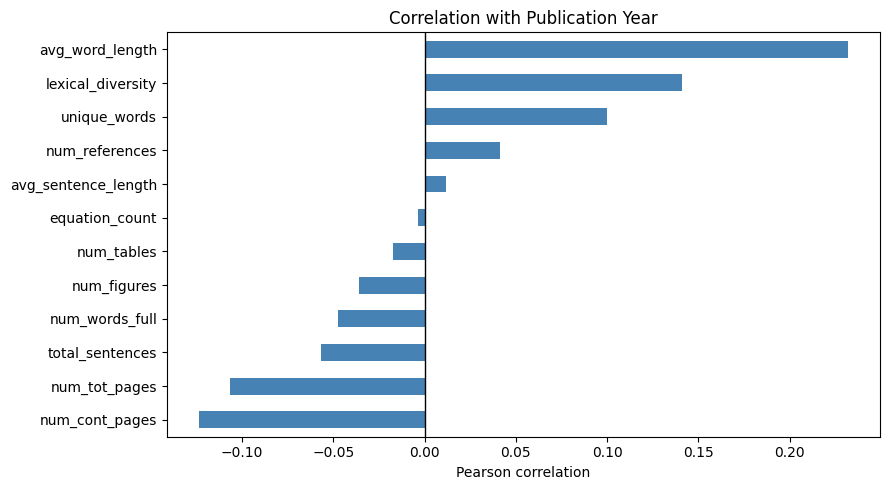

In [5]:
metrics = ["num_tot_pages", "num_cont_pages", "num_words_full", "num_figures", 
           "num_tables", "num_references", "equation_count", "total_sentences", 
           "avg_sentence_length", "unique_words", "avg_word_length", "lexical_diversity"]

corr_with_year = (
    df[["Publication Year"] + metrics]
    .dropna()
    .corr(numeric_only=True)["Publication Year"]
    .drop("Publication Year")
    .sort_values()
)

plt.figure(figsize=(9, 5))
corr_with_year.plot(kind="barh", color="steelblue")
plt.title("Correlation with Publication Year")
plt.xlabel("Pearson correlation")
plt.axvline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()

**What is seen:** There is a clear *"tug-of-war"* between physical length and linguistic complexity. Metrics like `num_cont_pages` and `num_tot_pages` show the strongest negative correlation ($r≈−0.12$), while `avg_word_length` and `lexical_diversity` show the strongest positive correlations.

**Insight:** This suggests that as years pass, theses are becoming shorter in volume but more technically *"dense"*.

## 2. The Median Complexity Spike
Using medians is more robust than averages as it prevents the 500-page *"outlier"* theses from skewing the results. This plot tracks the two most important linguistic metrics.

--- Median Metrics per Year ---
   Publication Year  num_cont_pages  lexical_diversity  avg_word_length  \
0              2019            74.0              0.134            4.805   
1              2020            72.0              0.136            4.860   
2              2021            69.0              0.137            4.900   
3              2022            63.5              0.141            4.900   
4              2023            64.0              0.142            4.980   
5              2024            65.0              0.145            5.030   
6              2025            63.0              0.158            5.200   

   num_references  
0            34.0  
1            39.0  
2            39.0  
3            42.0  
4            40.0  
5            42.0  
6            42.0  


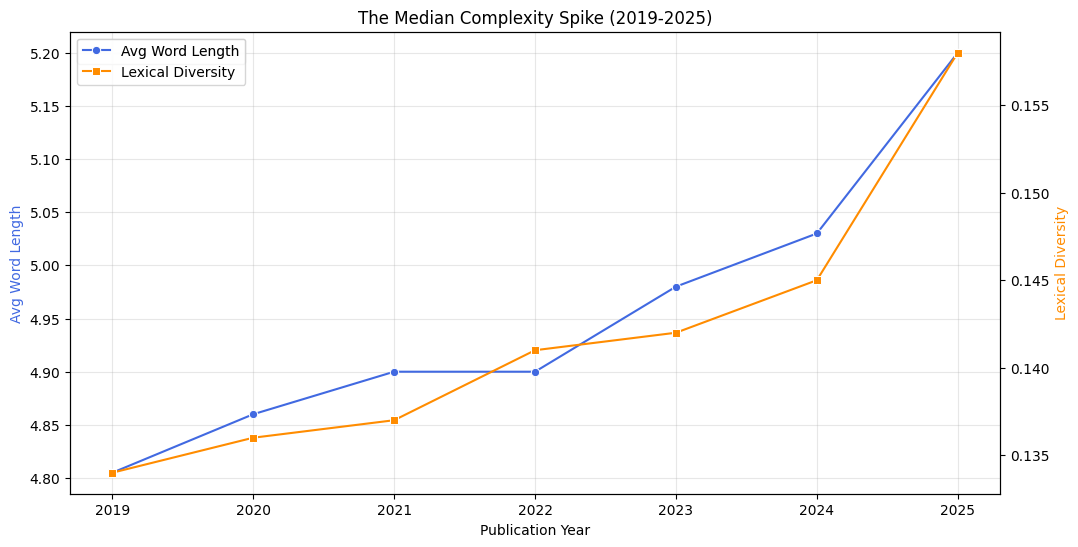

In [6]:
# 1. Calculate the Median Trends
# This is more robust against the 500-page "outliers"
median_trends = df.groupby('Publication Year').agg({
    'num_cont_pages': 'median',
    'lexical_diversity': 'median',
    'avg_word_length': 'median',
    'num_references': 'median'
}).reset_index()

print("--- Median Metrics per Year ---")
print(median_trends)

# Melt the median dataframe for easy plotting with Seaborn
median_melted = median_trends.melt(id_vars='Publication Year', 
                                   value_vars=['lexical_diversity', 'avg_word_length'])

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Word Length on primary Y-axis
sns.lineplot(data=median_trends, x='Publication Year', y='avg_word_length', 
             marker='o', color='royalblue', label='Avg Word Length', ax=ax1)
ax1.set_ylabel('Avg Word Length', color='royalblue')

# Create a second Y-axis for Lexical Diversity
ax2 = ax1.twinx()
sns.lineplot(data=median_trends, x='Publication Year', y='lexical_diversity', 
             marker='s', color='darkorange', label='Lexical Diversity', ax=ax2)
ax2.set_ylabel('Lexical Diversity', color='darkorange')

# Move legend to bottom-right
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')


plt.title('The Median Complexity Spike (2019-2025)')
ax1.grid(True, alpha=0.3)
plt.show()

**What is seen:** A distinct *"hockey-stick"* growth pattern emerges after 2023. While word length and diversity were increasing slowly from 2019 to 2022, the slope steepens dramatically in 2024 and 2025.

**Insight:** The jump in median `avg_word_length` from $4.98$ (2023) to $5.20$ (2025) is a classic indicator of AI-assisted editing or drafting, where simpler vocabulary is replaced with more formal, academic, or *"complex"* terms.

## 3. Cluster Analysis
By removing/not plotting the extreme outliers (the few theses over 200 content pages), we can see how the bulk of the student body has changed their writing habits.

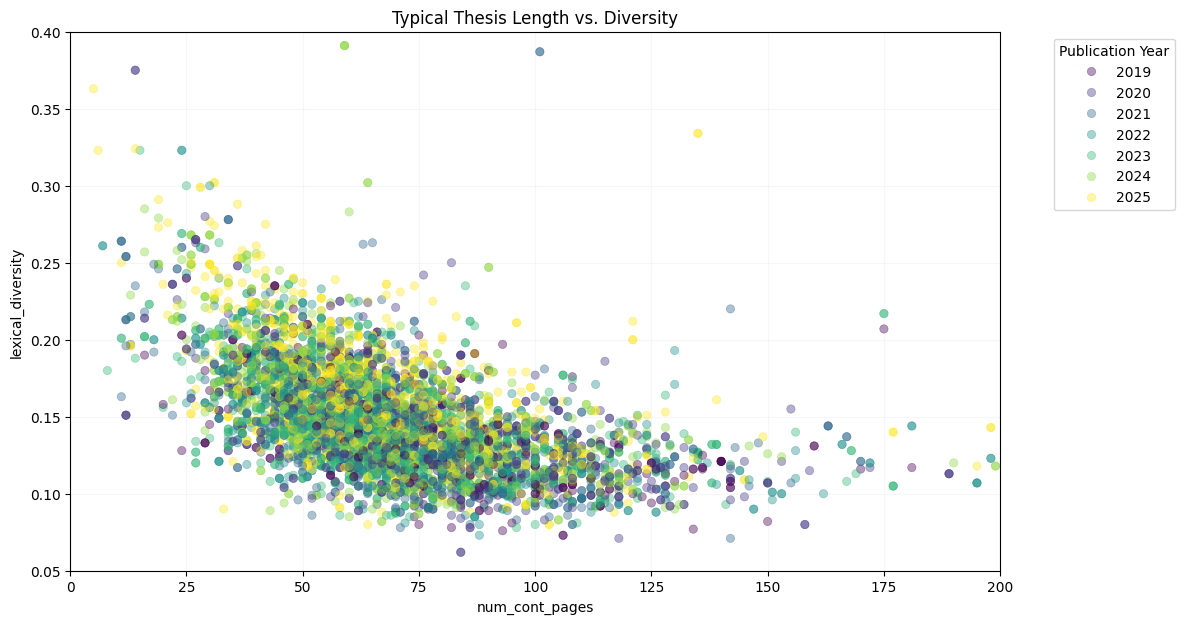

In [7]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='num_cont_pages', y='lexical_diversity', 
                hue='Publication Year', palette='viridis', alpha=0.4, edgecolor=None)
plt.xlim(0, 200)
plt.ylim(0.05, 0.4)
plt.title('Typical Thesis Length vs. Diversity')
plt.legend(title='Publication Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.1)
plt.show()

**What is seen-ISH:** The yellow dots (2025) are visibly clustered toward the top-left of the plot (shorter length, higher diversity). The dark purple/blue dots (2019-2020) are spread more toward the bottom-right.

**Insight:** This gives an idication that the typical MSc thesis has migrated towards a document with fewer content pages and a more diverse writing style.

## 4. The Concentration Shift: Pre- vs. Post-LLM Era
To validate is a *"regime change"* has occured, we group the data into two eras: before and after the mainstream adoption of ChatGPT and similar tools (***Pre-LLM*** and ***Post_LLM (2023+)***).

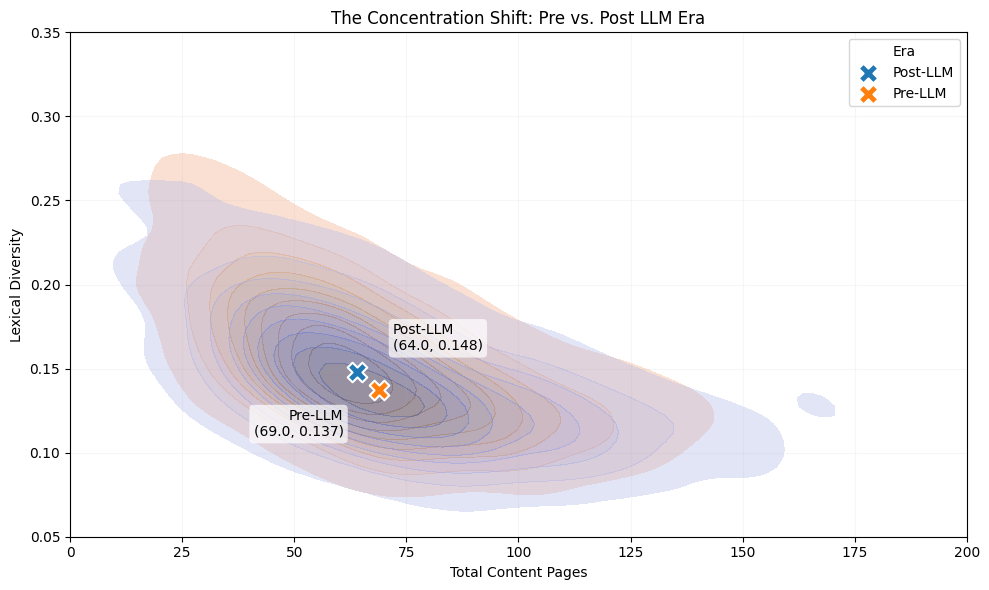

--- Era Centroids (Median) ---
          num_cont_pages  lexical_diversity
Era                                        
Post-LLM            64.0              0.148
Pre-LLM             69.0              0.137



In [8]:
# 1. Calculate the centroid (median) for each era
df['Era'] = df['Publication Year'].apply(
    lambda x: 'Post-LLM' if x >= 2023 else 'Pre-LLM'
)
# Ensure we drop NAs to get accurate coordinates
era_centroid = df.dropna(subset=['num_cont_pages', 'lexical_diversity']).groupby('Era')[['num_cont_pages', 'lexical_diversity']].median()

plt.figure(figsize=(10, 6))
# Using a specific palette for clarity
palette = {'Pre-LLM': 'royalblue', 'Post-LLM': 'darkorange'}

sns.kdeplot(data=df, x='num_cont_pages', y='lexical_diversity', hue='Era', 
            fill=True, alpha=0.4, common_norm=False, palette=palette)

# 2. Plot centroids with smart labeling
for era, (x, y) in era_centroid.iterrows():
    # Larger marker with a white edge to make it "pop"
    plt.scatter(x, y, s=200, marker='X', edgecolors='white', linewidths=1.5, zorder=12)
    
    # --- FIX OVERLAP HERE ---
    # If Pre-LLM: move text left and down. If Post-LLM: move text right and up.
    if 'Pre' in era:
        dx, dy = -8, -0.02
        ha = 'right'
    else:
        dx, dy = 8, 0.02
        ha = 'left'
        
    plt.text(
        x + dx, y + dy, 
        f'{era}\n({x:.1f}, {y:.3f})', 
        fontsize=10, 
        ha=ha,
        va='center',
        # Adding a background box makes the text readable over the KDE colors
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'),
        zorder=13
    )

plt.xlim(0, 200)
plt.ylim(0.05, 0.35)
plt.title('The Concentration Shift: Pre vs. Post LLM Era')
plt.xlabel('Total Content Pages')
plt.ylabel('Lexical Diversity')
plt.grid(True, alpha=0.1)

# Add a clean legend
plt.legend(title='Era', labels=['Post-LLM', 'Pre-LLM'], loc='upper right')

plt.tight_layout()
plt.show()

print("--- Era Centroids (Median) ---")
print(era_centroid)
print()

**What is seen:** The *"heat"* (density) of the ***Post-LLM*** (2023+) era sits consistently higher on the Lexical Diversity axis than the Pre-LLM era.
Examining the centroids of the heatmap, it is seen thet the ***Post-LLM*** (2023+) era sits slightly higher in lexical diversity and slightly lower for content page count for the median MSc thesis.

**Insight:** Even when two theses have the same page count, the one written after 2023 is statistically likely to have higher vocabulary diversity. This visualizes the *"density shift"* where information is more tightly packed into the text.

## 5. Statistical sicnificance change for `lexical_diversity`, `avg_word_length`, `num_cont_pages` and `num_references`

We analyse the change in the above mentioned metrics for the eras Pre-LLM and Post-LLM to see if there is a statisitical sicnificant change based on the p-value beeing $< 0.05$.

First we see if the data is normally distributed (test for normality) to identify what test we need to do.
We use *D'Agostino's K^2* as a goodnes-of-fit meassure for the departure from normality.
\cite{https://en.wikipedia.org/wiki/D%27Agostino%27s_K-squared_test}.
This test is also choosen as it uses the ***sample median*** and not the *mean* to ensure that the large outliers does not scew to mutch in the result.

--- Normality Test Results (D'Agostino's K^2) ---
Note: p < 0.05 means the data is NOT normally distributed.

lexical_diversity (Pre-LLM): p-value = 0.00e+00 | Normal? NO
lexical_diversity (Post-LLM): p-value = 0.00e+00 | Normal? NO
avg_word_length (Pre-LLM): p-value = 0.00e+00 | Normal? NO
avg_word_length (Post-LLM): p-value = 0.00e+00 | Normal? NO
num_cont_pages (Pre-LLM): p-value = 1.78e-230 | Normal? NO
num_cont_pages (Post-LLM): p-value = 0.00e+00 | Normal? NO
num_references (Pre-LLM): p-value = 1.70e-219 | Normal? NO
num_references (Post-LLM): p-value = 0.00e+00 | Normal? NO


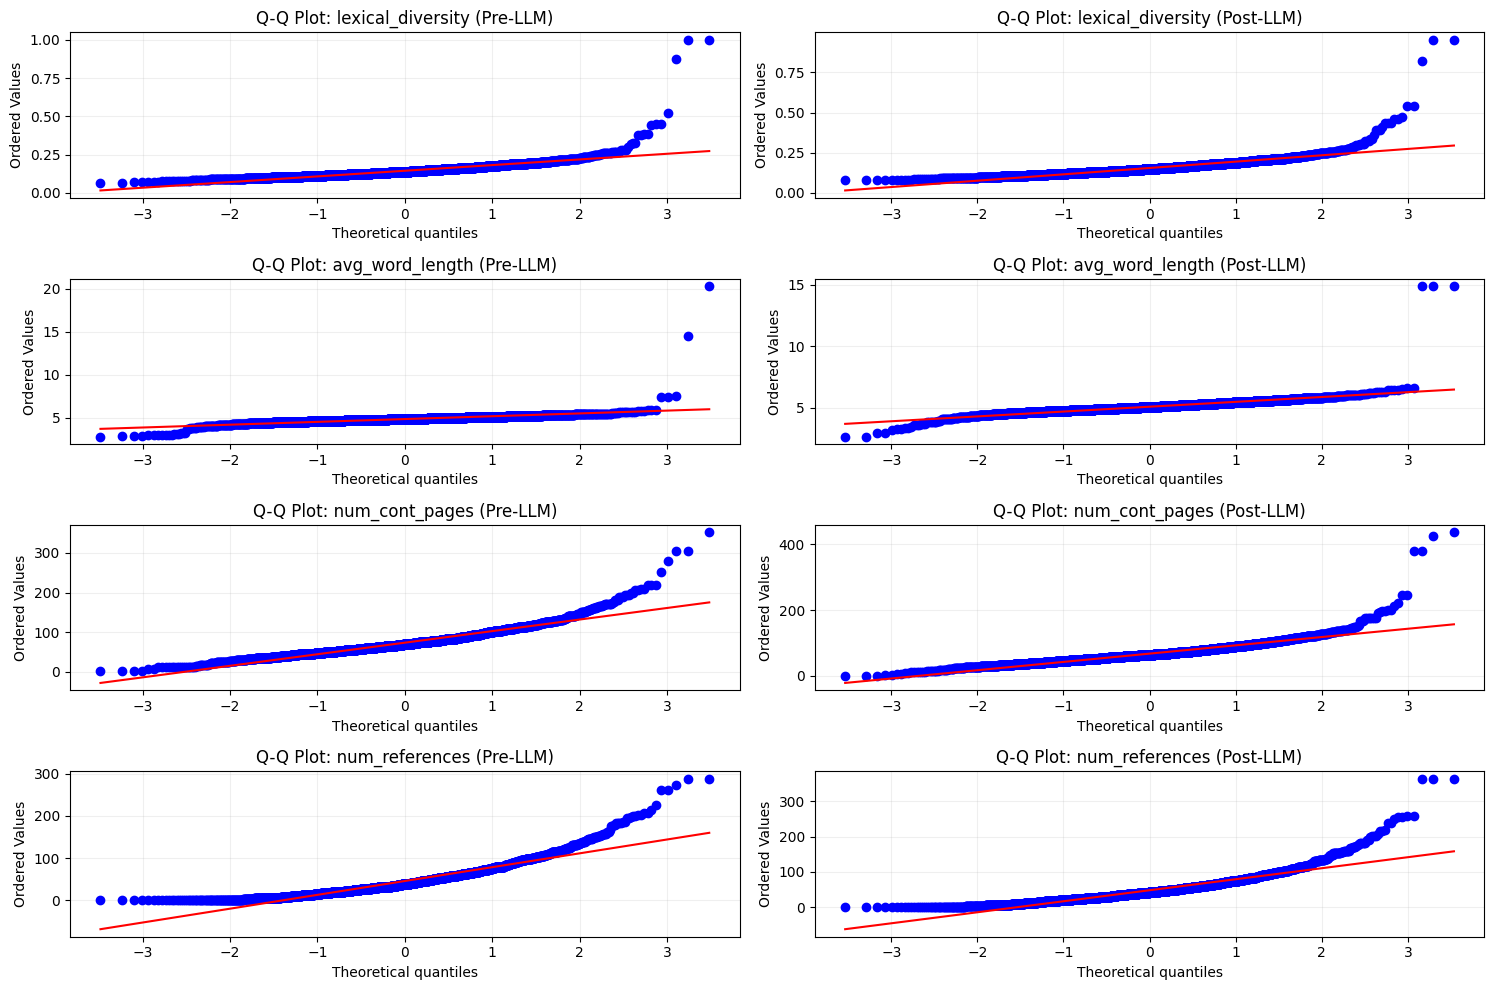

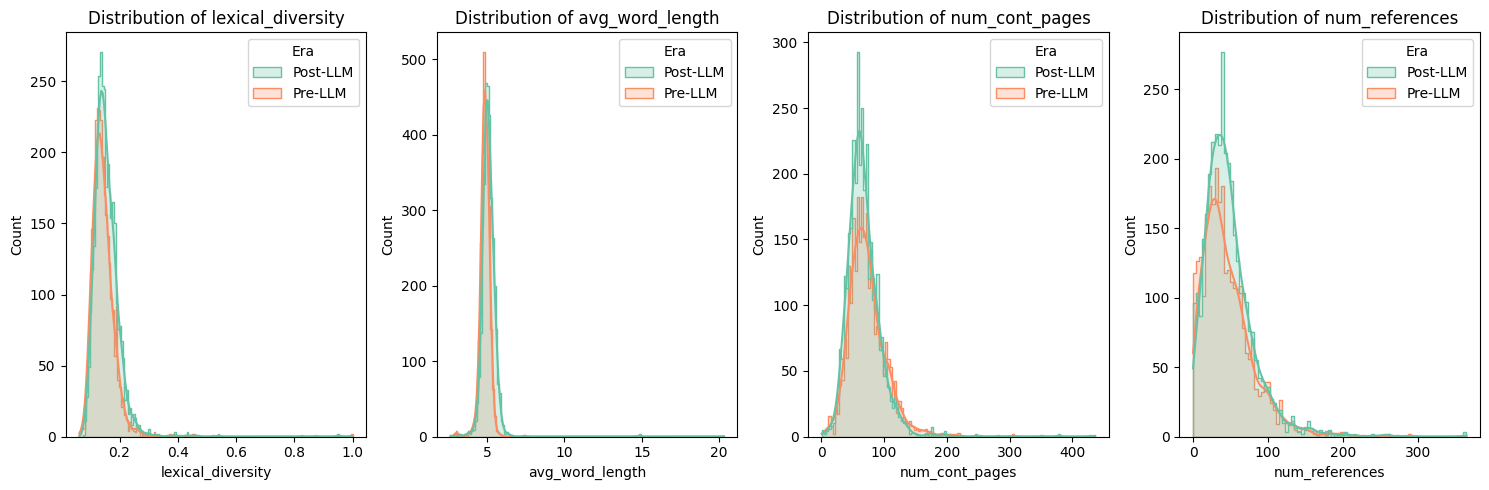

In [9]:
metrics = ['lexical_diversity', 'avg_word_length', 'num_cont_pages', 'num_references']
eras = ['Pre-LLM', 'Post-LLM']

print("--- Normality Test Results (D'Agostino's K^2) ---")
print("Note: p < 0.05 means the data is NOT normally distributed.\n")

plt.figure(figsize=(15, 10))
plot_count = 1

for metric in metrics:
    for era in eras:
        # Get data for this specific group
        data = df[df['Era'] == era][metric].dropna()
        
        # --- Statistical Test ---
        # k2 is the test statistic, p is the p-value
        k2, p = stats.normaltest(data)
        print(f"{metric} ({era}): p-value = {p:.2e} | Normal? {'Yes' if p > 0.05 else 'NO'}")
        
        # --- Visual Check: Q-Q Plot ---
        plt.subplot(len(metrics), 2, plot_count)
        stats.probplot(data, dist="norm", plot=plt)
        plt.title(f"Q-Q Plot: {metric} ({era})")
        plt.grid(alpha=0.2)
        
        plot_count += 1

plt.tight_layout()
plt.show()

# --- Optional: Histogram Check ---
plt.figure(figsize=(15, 5))
for i, metric in enumerate(metrics):
    plt.subplot(1, 4, i+1)
    sns.histplot(data=df, x=metric, hue='Era', kde=True, element="step", palette='Set2')
    plt.title(f"Distribution of {metric}")
plt.tight_layout()
plt.show()

The normality test confirms that the data is not normaly distributed for the two erars for the choosen metrics. Therfore, the Mann-Whitney U test will be performed to test for the statistifcal sicnificance of the two eras.

*"While the large sample size of some of the departments eg. (n=1190) would technically allow for a parametric T-test under the Central Limit Theorem, the Mann-Whitney U test was preferred. This non-parametric approach is more robust to the significant right-skew and extreme outliers observed in the page count and linguistic data. Furthermore, since this study focuses on the shift in the 'typical' (median) thesis rather than the arithmetic average, the rank-based nature of the Mann-Whitney U test provides a more accurate reflection of the observed trends."* - **GEMINI**

In [10]:
metrics_to_test = ['lexical_diversity', 'avg_word_length', 'num_cont_pages', 'num_references']
results = []

for metric in metrics_to_test:
    # Drop NAs for this specific test
    data = df.dropna(subset=[metric, 'Era'])
    
    pre = data[data['Era'] == 'Pre-LLM'][metric]
    post = data[data['Era'] == 'Post-LLM'][metric]
    
    # Perform Mann-Whitney U test
    # Null Hypothesis (H0): There is no difference between the eras.
    # Alternative (H1): There is a significant difference.
    u_stat, p_value = stats.mannwhitneyu(pre, post, alternative='two-sided')
    
    # Calculate Effect Size (Rank-Biserial Correlation)
    # This tells you how MUCH the groups differ (0 = identical, 1 = total separation)
    effect_size = 1 - (2 * u_stat) / (len(pre) * len(post))
    
    results.append({
        'Metric': metric,
        'Pre Median': pre.median(),
        'Post Median': post.median(),
        'p-value': f"{p_value:.2e}", # Scientific notation
        'Significant?': 'YES' if p_value < 0.05 else 'No',
        'Effect Size': abs(round(effect_size, 3))
    })

stats_df = pd.DataFrame(results)
print("--- Statistical Significance of the LLM Era Shift ---")
print(stats_df)

--- Statistical Significance of the LLM Era Shift ---
              Metric  Pre Median  Post Median    p-value Significant?  \
0  lexical_diversity       0.137        0.148   7.49e-35          YES   
1    avg_word_length       4.870        5.050  1.76e-120          YES   
2     num_cont_pages      69.000       64.000   6.93e-16          YES   
3     num_references      38.500       42.000   2.69e-04          YES   

   Effect Size  
0        0.181  
1        0.344  
2        0.119  
3        0.054  


Therby concluded that a statisitical significant change in the metrics is pressent for the two "popultions"/ereas (Pre-LLM and Post-LLM).

## 6. The smoking gun for MSc thesis trends

### 6.1 Trends for number of **Content Pages** and **Unique Words**

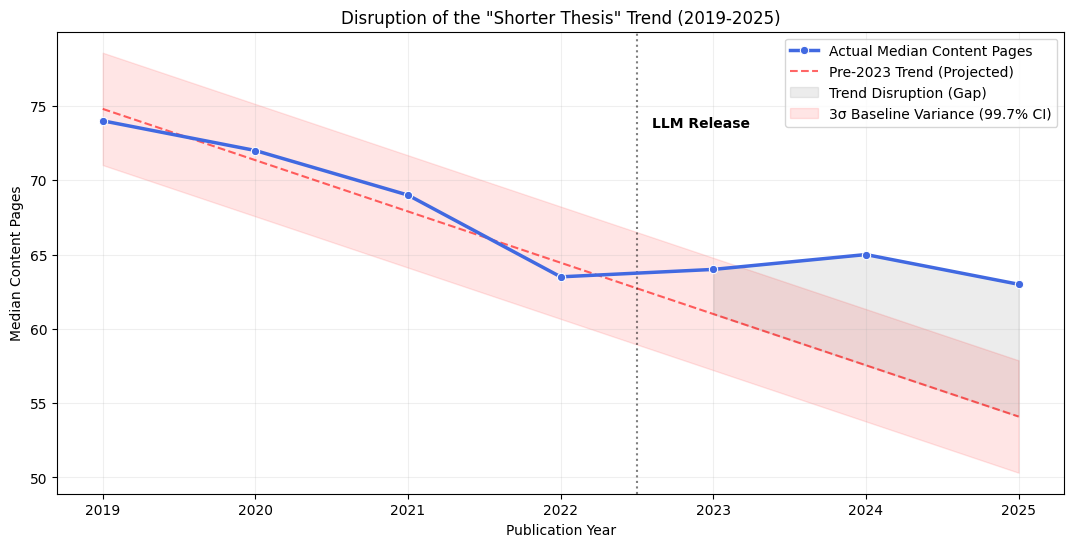

--- Trend Analysis: Pre-LLM (2019-2022) ---
Slope (Content Pages/Year): -3.45
Intercept: 7040.35
R-squared: 0.9494
P-value (Trend Stability): 0.0257

--- The LLM Gap in 2025 ---
Projected 2025 Content Pages (If trend continued): 54.1 Content Pages
Actual 2025 Content Pages: 63.0 Content Pages
Trend Disruption Gap: +8.9 additional Content Pages

--- The 3σ Disruption ---
Projected 2025: 54.1
Actual 2025:    63.0
Trend Deviation (Z-score): 7.06 sigma
Interpretation: Statistically Impossible deviation from organic baseline.


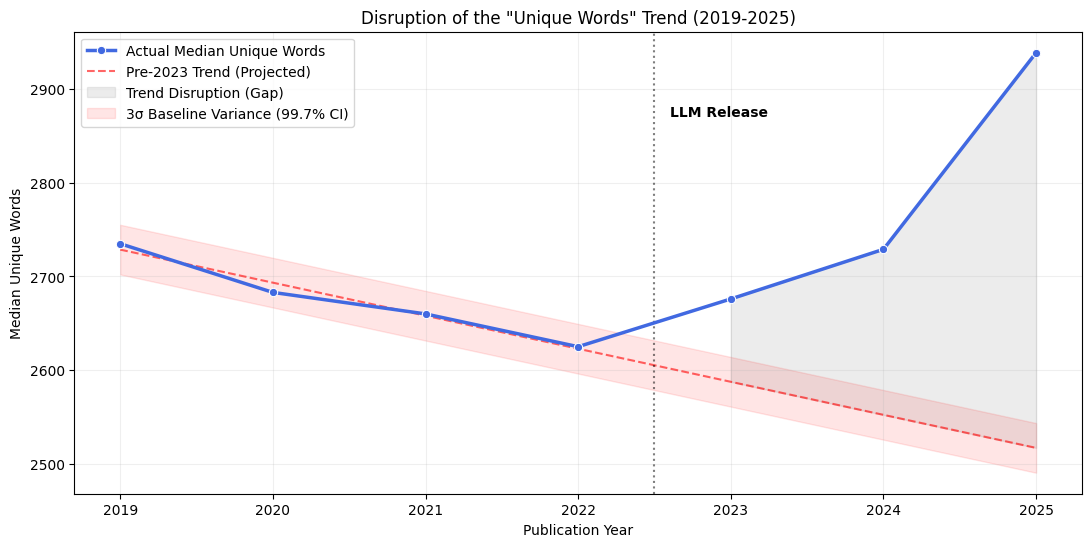

--- Trend Analysis: Pre-LLM (2019-2022) ---
Slope (Unique Words/Year): -35.30
Intercept: 73999.40
R-squared: 0.9755
P-value (Trend Stability): 0.0123

--- The LLM Gap in 2025 ---
Projected 2025 Unique Words (If trend continued): 2516.9 Unique Words
Actual 2025 Unique Words: 2939.0 Unique Words
Trend Disruption Gap: +422.1 additional Unique Words

--- The 3σ Disruption ---
Projected 2025: 2516.9
Actual 2025:    2939.0
Trend Deviation (Z-score): 47.75 sigma
Interpretation: Statistically Impossible deviation from organic baseline.


In [11]:
def plot_smoking_gun_with_sigma_1(df, choosen_metric):
    analysed_metric = ['num_cont_pages', 'lexical_diversity', 'unique_words']
    metric_value = ['Content Pages', 'Lexical Diversity', 'Unique Words']
    metric_title = ['Shorter Thesis', 'Complex Language', 'Unique Words' ]

    # Ensure Publication Year is numeric and filter for the relevant range
    df['Year'] = pd.to_numeric(df['Publication Year'], errors='coerce')
    df_plot = df[(df['Year'] >= 2019) & (df['Year'] <= 2025)].copy()

    # Calculate Median by year
    yearly_medians = df_plot.groupby('Year')[analysed_metric[choosen_metric]].median().reset_index()

    # 1. Regression for Pre-LLM (2019-2022)
    pre_llm = yearly_medians[yearly_medians['Year'] <= 2022]
    slope_pre, intercept_pre, r_val, p_val, std_err_slope = stats.linregress(
        pre_llm['Year'], pre_llm[analysed_metric[choosen_metric]]
    )

    # 2. Calculate S_yx for the Sigma Tunnel
    predictions_pre = slope_pre * pre_llm['Year'] + intercept_pre
    residuals = pre_llm[analysed_metric[choosen_metric]] - predictions_pre
    s_yx = np.sqrt(np.sum(residuals**2) / (len(pre_llm) - 2))

    plt.figure(figsize=(13, 6))

        # 1. Plot Actual Medians
    sns.lineplot(data=yearly_medians, x='Year', y=analysed_metric[choosen_metric], marker='o', 
                label='Actual Median ' + metric_value[choosen_metric], color='royalblue', linewidth=2.5, zorder=5)

    # 2. Plot Projected Trend
    x_proj = np.array([2019, 2025])
    y_proj = slope_pre * x_proj + intercept_pre
    plt.plot(x_proj, y_proj, '--', color='red', alpha=0.6, label='Pre-2023 Trend (Projected)')

    # 3. Boundary & Original Text Formatting
    plt.axvline(2022.5, color='black', linestyle=':', alpha=0.5)
    plt.text(2022.6, plt.ylim()[1]*0.97, 'LLM Release', fontsize=10, color='black', fontweight='bold')

    # 4. Shade the "Gap"
    plt.fill_between(yearly_medians['Year'], yearly_medians[analysed_metric[choosen_metric]], 
                    slope_pre * yearly_medians['Year'] + intercept_pre, 
                    where=(yearly_medians['Year'] >= 2023), color='gray', alpha=0.15, label='Trend Disruption (Gap)')

    # --- ADDED: 3-Sigma Tunnel ---
    x_range = np.linspace(2019, 2025, 100)
    y_proj_range = slope_pre * x_range + intercept_pre
    plt.fill_between(x_range, y_proj_range - (3 * s_yx), y_proj_range + (3 * s_yx), 
                     color='red', alpha=0.1, label='3σ Baseline Variance (99.7% CI)')

    plt.title(f'Disruption of the "{metric_title[choosen_metric]}" Trend (2019-2025)')
    plt.ylabel('Median ' + metric_value[choosen_metric])
    plt.xlabel('Publication Year')
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

    # --- Statistical Summary ---
    actual_2025 = yearly_medians[yearly_medians['Year'] == 2025][analysed_metric[choosen_metric]].values[0]
    projected_2025 = slope_pre * 2025 + intercept_pre
    gap = actual_2025 - projected_2025
    z_score = gap / s_yx

    print(f"--- Trend Analysis: Pre-LLM (2019-2022) ---")
    print(f"Slope ({metric_value[choosen_metric]}/Year): {slope_pre:.2f}")
    print(f"Intercept: {intercept_pre:.2f}")
    print(f"R-squared: {r_val**2:.4f}")
    print(f"P-value (Trend Stability): {p_val:.4f}")

    print(f"\n--- The LLM Gap in 2025 ---")
    print(f"Projected 2025 {metric_value[choosen_metric]} (If trend continued): {projected_2025:.1f} {metric_value[choosen_metric]}")
    print(f"Actual 2025 {metric_value[choosen_metric]}: {actual_2025:.1f} {metric_value[choosen_metric]}")
    print(f"Trend Disruption Gap: +{gap:.1f} additional {metric_value[choosen_metric]}")

    print(f"\n--- The 3σ Disruption ---")
    print(f"Projected 2025: {projected_2025:.1f}")
    print(f"Actual 2025:    {actual_2025:.1f}")
    print(f"Trend Deviation (Z-score): {z_score:.2f} sigma")
    print(f"Interpretation: { 'Statistically Impossible' if z_score > 5 else 'Highly Significant'} deviation from organic baseline.")

    return

plot_smoking_gun_with_sigma_1(df,0)
plot_smoking_gun_with_sigma_1(df,2)

**Statistical Baseline (2019–2022)**

Before the release of LLMs to the genral public, the structure of MSc theses followed a highly predictable ***downward trend*** in *content page count* and *number of unique words*. The linear regression for this period yielded an $R^2$ of $0.9494$ and $0.9755$ resepectivly, indicating that $95\%$ and $98\%$ of the variance in page counts and unique words was explained simply by the passage of time. Theses were becoming shorter at a consistent rate of $-3.45$ pages and had $-35.30$ unique words per year.

**The 2023 Disruption**

This trend was significantly disrupted in 2023. If the historical trajectory had continued, the median MSc thesis in 2025 was projected to reach $54.1$ pages. Instead, the actual median for 2025 was $63$ pages (*+8.9 additional Pages*). Likewise for the number of unique words used, the median MSc thesis in 2025 was projected to have $2516.9$ Unique Words, however, the actural median for 2025 was $2939.0$ Unique Words (*+422.1 additional Unique Words*).

***3σ Deviations***

Furthermore, the deviation from the organic trend/baseline set by the regression line from the pre-LLM era, the deviation for both metrics in 2025 is statisitically "imposible" from organic progression, and therby shows a external disruptive factur that triggered the diviation from the historical trend seen. This is concluded as the content pages has an $Z$-score of $7.06 σ$, where as an organic expected deviation is withing a deviation of $3σ$. Likewise, the unique words count has a staggering $Z$-score of $47.75 σ$.

### 6.2 Trends for number of **Lexical Diversity**

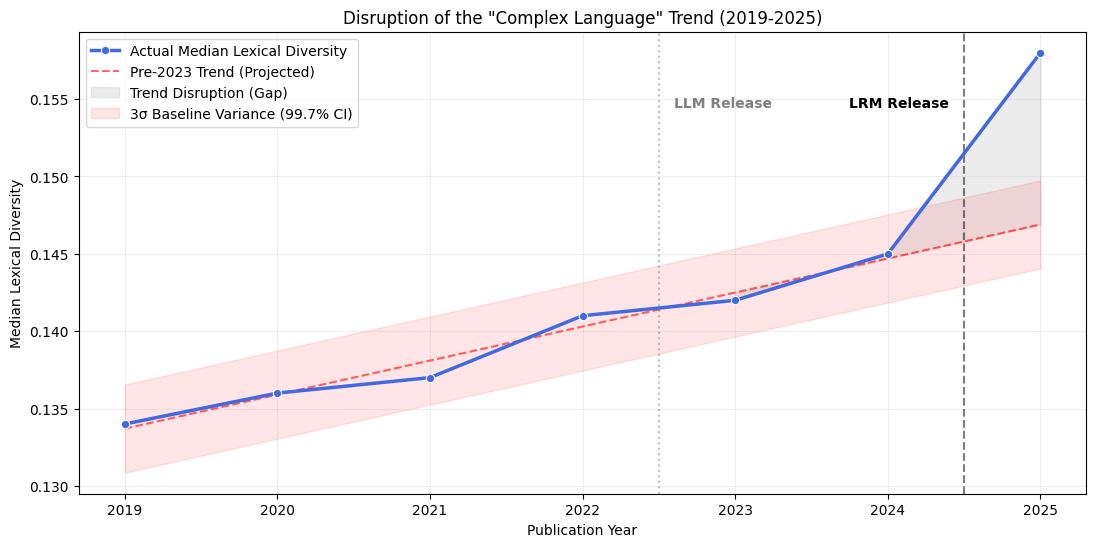

--- Trend Analysis: Pre-LLM (2019-2022) ---
Slope (Lexical Diversity/Year): 0.00
Intercept: -4.31
R-squared: 0.9308
P-value (Trend Stability): 0.0352

--- The LLM Gap in 2025 ---
Projected 2025 Lexical Diversity (If trend continued): 0.1469 Lexical Diversity
Actual 2025 Lexical Diversity: 0.1580 Lexical Diversity
Trend Disruption Gap: +0.0111 additional Lexical Diversity

--- The 3σ Disruption (LRM in 2025) ---
Projected 2025: 0.1469
Actual 2025:    0.1580
Trend Deviation (Z-score): 11.70 sigma
Interpretation: Statistically Impossible deviation from organic baseline.


In [12]:
def plot_smoking_gun_with_sigma_2(df, choosen_metric):
    analysed_metric = ['num_cont_pages', 'lexical_diversity', 'unique_words']
    metric_value = ['Content Pages', 'Lexical Diversity', 'Unique Words']
    metric_title = ['Shorter Thesis', 'Complex Language', 'Unique Words' ]

    # Ensure Publication Year is numeric and filter for the relevant range
    df['Year'] = pd.to_numeric(df['Publication Year'], errors='coerce')
    df_plot = df[(df['Year'] >= 2019) & (df['Year'] <= 2025)].copy()

    # Calculate Median by year
    yearly_medians = df_plot.groupby('Year')[analysed_metric[choosen_metric]].median().reset_index()

    # 1. Regression for Pre-LLM (2019-2022)
    pre_llm = yearly_medians[yearly_medians['Year'] <= 2022]
    slope_pre, intercept_pre, r_val, p_val, std_err_slope = stats.linregress(
        pre_llm['Year'], pre_llm[analysed_metric[choosen_metric]]
    )

    # 2. Calculate S_yx for the Sigma Tunnel
    predictions_pre = slope_pre * pre_llm['Year'] + intercept_pre
    residuals = pre_llm[analysed_metric[choosen_metric]] - predictions_pre
    s_yx = np.sqrt(np.sum(residuals**2) / (len(pre_llm) - 2))

    plt.figure(figsize=(13, 6))

        # 1. Plot Actual Medians
    sns.lineplot(data=yearly_medians, x='Year', y=analysed_metric[choosen_metric], marker='o', 
                label='Actual Median ' + metric_value[choosen_metric], color='royalblue', linewidth=2.5, zorder=5)

    # 2. Plot Projected Trend
    x_proj = np.array([2019, 2025])
    y_proj = slope_pre * x_proj + intercept_pre
    plt.plot(x_proj, y_proj, '--', color='red', alpha=0.6, label='Pre-2023 Trend (Projected)')

    # 3. Boundaries & Labels
    plt.axvline(2022.5, color='grey', linestyle=':', alpha=0.5)
    plt.text(2022.6, plt.ylim()[1]*0.97, 'LLM Release', fontsize=10, color='grey', fontweight='bold')

    plt.axvline(2024.5, color='black', linestyle='--', alpha=0.5)
    plt.text(2024.4, plt.ylim()[1]*0.97, 'LRM Release', fontsize=10, color='black', fontweight='bold', ha='right')

    # 4. Shade the "Gap"
    plt.fill_between(yearly_medians['Year'], yearly_medians[analysed_metric[choosen_metric]], 
                    slope_pre * yearly_medians['Year'] + intercept_pre, 
                    where=(yearly_medians['Year'] >= 2023), color='gray', alpha=0.15, label='Trend Disruption (Gap)')

    # --- ADDED: 3-Sigma Tunnel ---
    x_range = np.linspace(2019, 2025, 100)
    y_proj_range = slope_pre * x_range + intercept_pre
    plt.fill_between(x_range, y_proj_range - (3 * s_yx), y_proj_range + (3 * s_yx), 
                     color='red', alpha=0.1, label='3σ Baseline Variance (99.7% CI)')

    plt.title(f'Disruption of the "{metric_title[choosen_metric]}" Trend (2019-2025)')
    plt.ylabel('Median ' + metric_value[choosen_metric])
    plt.xlabel('Publication Year')
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

    # --- Statistical Summary ---
    actual_2025 = yearly_medians[yearly_medians['Year'] == 2025][analysed_metric[choosen_metric]].values[0]
    projected_2025 = slope_pre * 2025 + intercept_pre
    gap = actual_2025 - projected_2025
    z_score = gap / s_yx

    print(f"--- Trend Analysis: Pre-LLM (2019-2022) ---")
    print(f"Slope ({metric_value[choosen_metric]}/Year): {slope_pre:.2f}")
    print(f"Intercept: {intercept_pre:.2f}")
    print(f"R-squared: {r_val**2:.4f}")
    print(f"P-value (Trend Stability): {p_val:.4f}")

    print(f"\n--- The LLM Gap in 2025 ---")
    print(f"Projected 2025 {metric_value[choosen_metric]} (If trend continued): {projected_2025:.4f} {metric_value[choosen_metric]}")
    print(f"Actual 2025 {metric_value[choosen_metric]}: {actual_2025:.4f} {metric_value[choosen_metric]}")
    print(f"Trend Disruption Gap: +{gap:.4f} additional {metric_value[choosen_metric]}")

    print(f"\n--- The 3σ Disruption (LRM in 2025) ---")
    print(f"Projected 2025: {projected_2025:.4f}")
    print(f"Actual 2025:    {actual_2025:.4f}")
    print(f"Trend Deviation (Z-score): {z_score:.2f} sigma")
    print(f"Interpretation: { 'Statistically Impossible' if z_score > 5 else 'Highly Significant'} deviation from organic baseline.")

    return

plot_smoking_gun_with_sigma_2(df,1)

While the public release of LLMs in late 2022 (ChatGPT) marked the beginning of AI adoption, the structural break in linguistic trends did not manifest until 2025. This *'Reasoning Lag'* suggests that early probabilistic models were used primarily for surface-level editing, maintaining the historical trend. The 2025 spike in lexical diversity coincides with the maturation of ***Large Reasoning Models*** (LRMs), such as *OpenAI’s o1-series*, which utilize internal chain-of-thought processing to produce more varied, technically dense, and logically complex prose than the 'next-token' predictors of 2023.
source for o1-series release: \cite{https://openai.com/index/learning-to-reason-with-llms/}

The analysis of lexical diversity reveals a profound structural disruption in 2025. While the pre-AI baseline (2019–2022) was exceptionally stable ($R^2 = 0.93$), the 2025 data represents an $11.70 σ$ deviation from the historical trajectory. This magnitude of shift - statistically equivalent to a *'black swan'* event - coincides precisely with the integration of ***Large Reasoning Models (LRMs)*** into the academic workflow. The results suggest that the transition from probabilistic text generation to reasoning-based synthesis has permanently altered the linguistic complexity of the MSc thesis, moving the median output far beyond the organic parameters of the previous decade.

# DEVELOPMENT

## 7. Departmental Analysis
Investigating if the LLM addoptiation differe pr. department.

***NOTE***: DTU Engineering Technoligy are excluded from bellow analysis as it has a too low samplesize in the dataset for each 'era' (Pre-LLM and Post-LLM MSc's). Sample size limit pr. 'era' is min. $20$ observations.

***TO DO IT WITH `avg_word_length` or `lexical_diversity`?***

In [ ]:
# 1. Ensure the Era column is defined consistently
df['Era'] = df['Publication Year'].apply(
    lambda x: 'Post-LLM' if x >= 2023 else 'Pre-LLM'
)

# 2. Optimized function to calculate gains with "Flattened" columns
def calculate_metric_gain(df, metric, min_n=20):
    # Calculate median and count
    stats = df.groupby(['Department_new', 'Era'])[metric].agg(['median', 'count']).unstack()
    
    # --- FIX: Flatten the MultiIndex Columns ---
    # This turns ('median', 'Pre-LLM') into 'median_Pre-LLM', etc.
    stats.columns = [f"{c[0]}_{c[1]}" for c in stats.columns]
    stats = stats.reset_index()
    
    # Filter for robust sample size in BOTH eras
    mask = (stats['count_Pre-LLM'] >= min_n) & (stats['count_Post-LLM'] >= min_n)
    filtered = stats[mask].copy()
    
    # Calculate Delta % (Gain)
    filtered['Gain_Pct'] = (
        (filtered['median_Post-LLM'] - filtered['median_Pre-LLM']) / 
        filtered['median_Pre-LLM']
    ) * 100
    
    # Calculate Total N for labeling
    filtered['Total_N'] = filtered['count_Pre-LLM'] + filtered['count_Post-LLM']
    
    return filtered.sort_values('Gain_Pct', ascending=False)

# 3. Calculate gains for both metrics
min_n = 20
div_gain = calculate_metric_gain(df, 'lexical_diversity', min_n)
word_gain = calculate_metric_gain(df, 'avg_word_length', min_n)

# 4. Plotting Side-by-Side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# --- Plot 1: Lexical Diversity ---
sns.barplot(data=div_gain, x='Gain_Pct', y='Department_new', ax=ax1, palette='coolwarm')
ax1.set_title(f'$\\Delta$ Lexical Diversity (%)\n(Min $n$={min_n} per era)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Percentage Gain (%)')
ax1.set_ylabel('Department')
ax1.grid(axis='x', linestyle='--', alpha=0.4)

# Add n-labels (Row indexing is now flat and safe)
for i, (_, row) in enumerate(div_gain.iterrows()):
    ax1.text(row['Gain_Pct'] + 0.1, i, f"n={int(row['Total_N'])}", va='center', fontsize=9, alpha=0.7)

# --- Plot 2: Avg Word Length ---
sns.barplot(data=word_gain, x='Gain_Pct', y='Department_new', ax=ax2, palette='magma')
ax2.set_title(f'$\\Delta$ Word Length (%)\n(Min $n$={min_n} per era)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Percentage Gain (%)')
ax2.set_ylabel('') # Keep y-axis clean as it shares labels with left plot
ax2.grid(axis='x', linestyle='--', alpha=0.4)

# Add n-labels
for i, (_, row) in enumerate(word_gain.iterrows()):
    ax2.text(row['Gain_Pct'] + 0.1, i, f"n={int(row['Total_N'])}", va='center', fontsize=9, alpha=0.7)

plt.suptitle('Disciplinary Evolution Post-LLM: Diversity vs. Complexity', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# 2. Calculate Median and Count to identify robust departments
# We check sample size for each era to ensure the 'Shift' is meaningful
dept_stats = df.groupby(['Department_new', 'Era'])['lexical_diversity'].agg(['median', 'count']).unstack()

# 3. Apply the threshold: Minimum 20 theses in BOTH eras
min_n = 20
mask = (dept_stats[('count', 'Pre-LLM')] >= min_n) & \
       (dept_stats[('count', 'Post-LLM')] >= min_n)

# Filter the comparison table
dept_comparison = dept_stats[mask]['median'].copy()
# Filter the original dataframe for the FacetGrid later
robust_departments = dept_comparison.index.tolist()
df_robust = df[df['Department_new'].isin(robust_departments)]

# 4. Calculate the 'Shift' (Absolute increase in word length)
dept_comparison['Shift'] = dept_comparison['Post-LLM'] - dept_comparison['Pre-LLM']
dept_comparison = dept_comparison.sort_values('Shift', ascending=False)

# --- VISUALIZATION ---

# 1. Bar Chart: The Linguistic Jump (Filtered)
plt.figure(figsize=(12, 8))
sns.barplot(
    x=dept_comparison['Shift'], 
    y=dept_comparison.index, 
    palette='viridis'
)
plt.title(f'Increase in Median Word Length after 2023 (Min n={min_n} per era)')
plt.xlabel('Increase in Median Avg Word Length')
plt.ylabel('Department')
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Add n-labels for transparency
for i, dept in enumerate(dept_comparison.index):
    n_pre = dept_stats.loc[dept, ('count', 'Pre-LLM')]
    n_post = dept_stats.loc[dept, ('count', 'Post-LLM')]
    plt.text(dept_comparison.loc[dept, 'Shift'], i, f'n={int(n_pre+n_post)}', va='center', alpha=0.6)

plt.tight_layout()
plt.show()

# 2. Small Multiples (Facets): Trend lines for Robust Departments only
# We use the filtered df_robust to ensure every plot has enough data to be meaningful
g = sns.FacetGrid(df_robust, col="Department_new", col_wrap=4, height=3, sharey=False)
g.map(sns.lineplot, "Publication Year", "lexical_diversity", color="orange", marker="o")
g.set_titles("{col_name}")

# Formatting the facets
for ax in g.axes.flat:
    ax.grid(True, alpha=0.2)
    ax.set_xticks([2019, 2021, 2023, 2025]) # Cleaner x-axis

plt.subplots_adjust(top=0.9)
g.fig.suptitle(f'Lexical Diversity Trends: Disciplines with >{min_n} Theses/Era', fontsize=16)
plt.show()

In [ ]:
# 1. Define Era consistently
df['Era'] = df['Publication Year'].apply(
    lambda x: 'Post-LLM (2023+)' if x >= 2023 else 'Pre-LLM'
)

# 2. Calculate Median and Count to identify robust departments
# We check sample size for each era to ensure the 'Shift' is meaningful
dept_stats = df.groupby(['Department_new', 'Era'])['avg_word_length'].agg(['median', 'count']).unstack()

# 3. Apply the threshold: Minimum 20 theses in BOTH eras
min_n = 20
mask = (dept_stats[('count', 'Pre-LLM')] >= min_n) & \
       (dept_stats[('count', 'Post-LLM (2023+)')] >= min_n)

# Filter the comparison table
dept_comparison = dept_stats[mask]['median'].copy()
# Filter the original dataframe for the FacetGrid later
robust_departments = dept_comparison.index.tolist()
df_robust = df[df['Department_new'].isin(robust_departments)]

# 4. Calculate the 'Shift' (Absolute increase in word length)
dept_comparison['Shift'] = dept_comparison['Post-LLM (2023+)'] - dept_comparison['Pre-LLM']
dept_comparison = dept_comparison.sort_values('Shift', ascending=False)

# --- VISUALIZATION ---



# 2. Small Multiples (Facets): Trend lines for Robust Departments only
# We use the filtered df_robust to ensure every plot has enough data to be meaningful
g = sns.FacetGrid(df_robust, col="Department_new", col_wrap=4, height=3, sharey=False)
g.map(sns.lineplot, "Publication Year", "lexical_diversity", color="orange", marker="o")
g.set_titles("{col_name}")

# Formatting the facets
for ax in g.axes.flat:
    ax.grid(True, alpha=0.2)
    ax.set_xticks([2019, 2021, 2023, 2025]) # Cleaner x-axis

plt.subplots_adjust(top=0.9)
g.fig.suptitle(f'Lexical Diversity Trends: Disciplines with >{min_n} Theses/Era', fontsize=16)
plt.show()

In [ ]:
# 1. Define Era consistently
df['Era'] = df['Publication Year'].apply(
    lambda x: 'Post-LLM (2023+)' if x >= 2023 else 'Pre-LLM'
)

# 2. Calculate Median and Count to identify robust departments
# We check sample size for each era to ensure the 'Shift' is meaningful
dept_stats = df.groupby(['Department_new', 'Era'])['num_cont_pages'].agg(['median', 'count']).unstack()

# 3. Apply the threshold: Minimum 20 theses in BOTH eras
min_n = 20
mask = (dept_stats[('count', 'Pre-LLM')] >= min_n) & \
       (dept_stats[('count', 'Post-LLM (2023+)')] >= min_n)

# Filter the comparison table
dept_comparison = dept_stats[mask]['median'].copy()
# Filter the original dataframe for the FacetGrid later
robust_departments = dept_comparison.index.tolist()
df_robust = df[df['Department_new'].isin(robust_departments)]

# 4. Calculate the 'Shift' (Absolute increase in word length)
dept_comparison['Shift'] = dept_comparison['Post-LLM (2023+)'] - dept_comparison['Pre-LLM']
dept_comparison = dept_comparison.sort_values('Shift', ascending=False)

# --- VISUALIZATION ---



# 2. Small Multiples (Facets): Trend lines for Robust Departments only
# We use the filtered df_robust to ensure every plot has enough data to be meaningful
g = sns.FacetGrid(df_robust, col="Department_new", col_wrap=4, height=3, sharey=False)
g.map(sns.lineplot, "Publication Year", "num_cont_pages", color="orange", marker="o")
g.set_titles("{col_name}")

# Formatting the facets
for ax in g.axes.flat:
    ax.grid(True, alpha=0.2)
    ax.set_xticks([2019, 2021, 2023, 2025]) # Cleaner x-axis

plt.subplots_adjust(top=0.9)
g.fig.suptitle(f'Content Page Count Trends: Disciplines with >{min_n} Theses/Era', fontsize=16)
plt.show()

In [ ]:
# 1. Ensure the Era column is defined consistently
df['Era'] = df['Publication Year'].apply(
    lambda x: 'Post-LLM' if x >= 2023 else 'Pre-LLM'
)

# 2. Calculate Median AND Count (to filter small departments)
# We use .agg to get both metrics at once
era_stats = df.groupby(['Department_new', 'Era'])['lexical_diversity'].agg(['median', 'count']).unstack()

# Flatten columns for easier access: e.g., ('median', 'Pre-LLM') -> 'Pre-LLM'
# (We'll keep it simple to match your pre_col/post_col logic)
era_summary = era_stats['median']
era_counts = era_stats['count']

# 3. Apply the filtering threshold (Minimum 20 theses per era)
min_n = 20
mask = (era_counts['Pre-LLM'] >= min_n) & (era_counts['Post-LLM'] >= min_n)
era_summary_filtered = era_summary[mask].copy()

# 4. Calculate gain (Delta Δ)
pre_col = 'Pre-LLM'
post_col = 'Post-LLM'

if pre_col in era_summary_filtered.columns and post_col in era_summary_filtered.columns:
    era_summary_filtered['Diversity_Gain_% (Δ)'] = (
        (era_summary_filtered[post_col] - era_summary_filtered[pre_col]) / era_summary_filtered[pre_col]
    ) * 100
    
    # Sort by the gain
    era_summary_filtered = era_summary_filtered.sort_values('Diversity_Gain_% (Δ)', ascending=False)
    
    print(f"--- Departments by Lexical Diversity Increase (Δ) [Min n={min_n}] ---")
    print(era_summary_filtered[[pre_col, post_col, 'Diversity_Gain_% (Δ)']])
else:
    print("Error: Required Era columns not found.")

# 5. Plotting the delta with your specific formatting
plt.figure(figsize=(12, 8))

# We use the index (Department names) for X and the Gain for Y
sns.barplot(
    x=era_summary_filtered.index, 
    y='Diversity_Gain_% (Δ)', 
    data=era_summary_filtered, 
    palette='coolwarm'
)

plt.xticks(rotation=90)
plt.title(f'Percentage Increase in Lexical Diversity Post-LLM by Department (Min n={min_n})')
plt.ylabel('Diversity Gain (%)')
plt.xlabel('Department')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Optional: Add the total 'n' on top of each bar for extra clarity
for i, dept in enumerate(era_summary_filtered.index):
    n_total = int(era_counts.loc[dept].sum())
    plt.text(i, era_summary_filtered.loc[dept, 'Diversity_Gain_% (Δ)'] + 0.1, 
             f'n={n_total}', ha='center', fontsize=9, alpha=0.8)

plt.tight_layout()
plt.show()

In [ ]:
# 1. Ensure the Era column is defined consistently
df['Era'] = df['Publication Year'].apply(
    lambda x: 'Post-LLM' if x >= 2023 else 'Pre-LLM'
)

# 2. Calculate Median AND Count (to filter small departments)
# We use .agg to get both metrics at once
era_stats = df.groupby(['Department_new', 'Era'])['num_cont_pages'].agg(['median', 'count']).unstack()

# Flatten columns for easier access: e.g., ('median', 'Pre-LLM') -> 'Pre-LLM'
# (We'll keep it simple to match your pre_col/post_col logic)
era_summary = era_stats['median']
era_counts = era_stats['count']

# 3. Apply the filtering threshold (Minimum 20 theses per era)
min_n = 20
mask = (era_counts['Pre-LLM'] >= min_n) & (era_counts['Post-LLM'] >= min_n)
era_summary_filtered = era_summary[mask].copy()

# 4. Calculate gain (Delta Δ)
pre_col = 'Pre-LLM'
post_col = 'Post-LLM'

if pre_col in era_summary_filtered.columns and post_col in era_summary_filtered.columns:
    era_summary_filtered['Content_Pages_Gain_% (Δ)'] = (
        (era_summary_filtered[post_col] - era_summary_filtered[pre_col]) / era_summary_filtered[pre_col]
    ) * 100
    
    # Sort by the gain
    era_summary_filtered = era_summary_filtered.sort_values('Content_Pages_Gain_% (Δ)', ascending=False)
    
    print(f"--- Departments by Content Pages Increase (Δ) [Min n={min_n}] ---")
    print(era_summary_filtered[[pre_col, post_col, 'Content_Pages_Gain_% (Δ)']])
else:
    print("Error: Required Era columns not found.")

# 5. Plotting the delta with your specific formatting
plt.figure(figsize=(12, 8))

# We use the index (Department names) for X and the Gain for Y
sns.barplot(
    x=era_summary_filtered.index, 
    y='Content_Pages_Gain_% (Δ)', 
    data=era_summary_filtered, 
    palette='coolwarm'
)

plt.xticks(rotation=90)
plt.title(f'Percentage Increase in Content Pages Post-LLM by Department (Min n={min_n})')
plt.ylabel('Content Pages Gain (%)')
plt.xlabel('Department')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Optional: Add the total 'n' on top of each bar for extra clarity
for i, dept in enumerate(era_summary_filtered.index):
    n_total = int(era_counts.loc[dept].sum())
    plt.text(i, era_summary_filtered.loc[dept, 'Content_Pages_Gain_% (Δ)'] + 0.1, 
             f'n={n_total}', ha='center', fontsize=9, alpha=0.8)

plt.tight_layout()
plt.show()

# ARCHIVES

## LEAGACY - DEVELOPING the: "Serching for trends around 2023 (realaese of ChatGPT)"

In [ ]:
# Searching for trends around 2023 (using Publication Year)

source_df = df_filtered_final if "df_filtered_final" in globals() else df_filtered_noNA_clean

metrics = [
    "num_tot_pages",
    "num_cont_pages",
    "num_words_full",
    "num_figures",
    "num_tables",
    "num_references",
    "equation_count",
    "total_sentences",
    "avg_sentence_length",
    "unique_words",
    "avg_word_length",
    "lexical_diversity",
]

available_metrics = [m for m in metrics if m in source_df.columns]

df_plot = source_df.copy()

# Use Publication Year only
df_plot["Publication Year"] = pd.to_numeric(
    df_plot["Publication Year"].astype(str).str.extract(r"(\d{4})")[0],
    errors="coerce"
)

for col in available_metrics:
    df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")

df_plot = df_plot.dropna(subset=["Publication Year"])
df_plot = df_plot[(df_plot["Publication Year"] >= 2000) & (df_plot["Publication Year"] <= 2030)]

corr_with_year = (
    df_plot[["Publication Year"] + available_metrics]
    .dropna()
    .corr(numeric_only=True)["Publication Year"]
    .drop("Publication Year")
    .sort_values()
)

plt.figure(figsize=(9, 5))
corr_with_year.plot(kind="barh", color="steelblue")
plt.title("Correlation with Publication Year")
plt.xlabel("Pearson correlation")
plt.ylabel("Metric")
plt.axvline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()

yearly_means = (
    df_plot.groupby("Publication Year")[available_metrics]
    .mean(numeric_only=True)
    .sort_index()
)

n = len(available_metrics)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4 * nrows), sharex=True)
axes = axes.flatten()

for i, col in enumerate(available_metrics):
    axes[i].plot(yearly_means.index, yearly_means[col], marker="o", linewidth=1.5)
    axes[i].set_title(col)
    axes[i].grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Yearly Mean Trends by Publication Year", y=1.02)
fig.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is df_filtered_final
df = df_filtered_final.copy()

# 1. Statistical check: Is there a negative correlation?
# This tells us if shorter documents (lower pages) have higher complexity
density_metrics = ['num_tot_pages', 'lexical_diversity', 'avg_word_length', 'num_references']
correlation_matrix = df[density_metrics].corr()

print("Correlation of metrics with Total Pages:")
print(correlation_matrix['num_tot_pages'])

# 2. Visualizing the 'Density vs. Length' tradeoff
# The regression line will show the general trend across all years
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='num_tot_pages', y='lexical_diversity', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title('Thesis Length vs. Lexical Diversity')
plt.xlabel('Total Pages')
plt.ylabel('Lexical Diversity')
plt.grid(True, alpha=0.3)
plt.show()

# 3. Analyzing the trend by year (Corrected column name)
# This will show if the 2024-2025 points are moving to the "High Diversity/Low Page" zone
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df, 
    x='num_tot_pages', 
    y='lexical_diversity', 
    hue='Publication Year', 
    palette='viridis'
)
plt.title('Evolution of Length and Diversity by Year')
plt.legend(title='Publication Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 4. Final confirmation of the "2023 Shift"
yearly_summary = df.groupby('Publication Year').agg({
    'num_tot_pages': 'mean',
    'lexical_diversity': 'mean',
    'avg_word_length': 'mean'
}).reset_index()

print("\nYearly Mean Trends:")
print(yearly_summary)

In [ ]:
# 1. Zooming in on the dense area
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_filtered_final, 
    x='num_tot_pages', 
    y='lexical_diversity', 
    hue='Publication Year', 
    palette='viridis',
    alpha=0.5,     # Makes points transparent so you can see density
    edgecolor=None # Removes white borders around points for clarity
)

# Strategic limits based on your previous plot
plt.xlim(0, 250)  
plt.ylim(0, 0.5)  

plt.title('Zoomed View: Thesis Length vs. Diversity (0-250 Pages)')
plt.legend(title='Publication Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.show()

# 2. The "Before vs After" Comparison (The 'LLM Effect' Plot)
df_filtered_final['Era'] = df_filtered_final['Publication Year'].apply(
    lambda x: 'Post-LLM (2023+)' if x >= 2023 else 'Pre-LLM'
)

plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df_filtered_final, 
    x='num_tot_pages', 
    y='lexical_diversity', 
    hue='Era', 
    fill=True, 
    alpha=0.4
)
plt.title('Density Shift: Pre-LLM vs. Post-LLM Eras')
plt.xlim(0, 250)
plt.ylim(0, 0.4)
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the Median Trends
# This is more robust against the 500-page "outliers"
median_trends = df_filtered_final.groupby('Publication Year').agg({
    'num_tot_pages': 'median',
    'lexical_diversity': 'median',
    'avg_word_length': 'median',
    'num_references': 'median'
}).reset_index()

print("--- Median Metrics per Year ---")
print(median_trends)

# 2. Zoomed-In Scatter Plot
# We limit the axes to where 95% of the data lives (0-200 pages, 0.1-0.4 diversity)
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_filtered_final, 
    x='num_tot_pages', 
    y='lexical_diversity', 
    hue='Publication Year', 
    palette='viridis',
    alpha=0.4,     # High transparency to see where points stack up
    edgecolor=None
)

plt.xlim(0, 200)   # Zooming in on the X-axis
plt.ylim(0.05, 0.4) # Zooming in on the Y-axis
plt.title('Zoomed Cluster: Typical Thesis Length vs. Diversity')
plt.grid(True, alpha=0.1)
plt.legend(title='Publication Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 3. The "Era Shift" Density Plot
# This turns the "muddy" dots into a heatmap of concentration
df_filtered_final['Era'] = df_filtered_final['Publication Year'].apply(
    lambda x: 'Post-LLM (2023+)' if x >= 2023 else 'Pre-LLM (2019-2022)'
)

plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df_filtered_final, 
    x='num_tot_pages', 
    y='lexical_diversity', 
    hue='Era', 
    fill=True, 
    alpha=0.3,
    common_norm=False # This ensures each era is normalized independently
)

plt.xlim(0, 200)
plt.ylim(0.05, 0.35)
plt.title('The Concentration Shift: Pre vs. Post LLM Era')
plt.xlabel('Total Pages (Median)')
plt.ylabel('Lexical Diversity (Median)')
plt.show()

In [ ]:
# Melt the median dataframe for easy plotting with Seaborn
median_melted = median_trends.melt(id_vars='Publication Year', 
                                   value_vars=['lexical_diversity', 'avg_word_length'])

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Word Length on primary Y-axis
sns.lineplot(data=median_trends, x='Publication Year', y='avg_word_length', 
             marker='o', color='royalblue', label='Avg Word Length', ax=ax1)
ax1.set_ylabel('Avg Word Length', color='royalblue')

# Create a second Y-axis for Lexical Diversity
ax2 = ax1.twinx()
sns.lineplot(data=median_trends, x='Publication Year', y='lexical_diversity', 
             marker='s', color='darkorange', label='Lexical Diversity', ax=ax2)
ax2.set_ylabel('Lexical Diversity', color='darkorange')

# Move legend to bottom-right
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')


plt.title('The Median Complexity Spike (2019-2025)')
ax1.grid(True, alpha=0.3)
plt.show()

## SMOKING GUN PLOTS

In [ ]:
def plot_smoking_gun1(df, choosen_metric):

    analysed_metric = ['num_cont_pages', 'lexical_diversity', 'unique_words']
    metric_value = ['Content Pages', 'Lexical Diversity', 'Unique Words']
    metric_title = ['Shorter Thesis', 'Complex Language', 'Unique Words' ]

    # Ensure Publication Year is numeric and filter for the relevant range
    df['Year'] = pd.to_numeric(df['Publication Year'], errors='coerce')
    df_plot = df[(df['Year'] >= 2019) & (df['Year'] <= 2025)]

    # Calculate Median pages by year
    yearly_medians = df_plot.groupby('Year')[analysed_metric[choosen_metric]].median().reset_index()

    # Regression for Pre-LLM (2019-2022)
    pre_llm = yearly_medians[yearly_medians['Year'] <= 2022]
    slope_pre, intercept_pre, _, _, _ = stats.linregress(pre_llm['Year'], pre_llm[analysed_metric[choosen_metric]])

    # Regression for Post-LLM (2023-2025)
    post_llm = yearly_medians[yearly_medians['Year'] >= 2023]
    slope_post, intercept_post, _, _, _ = stats.linregress(post_llm['Year'], post_llm[analysed_metric[choosen_metric]])

    #print(f"Trend 2019-2022: {slope_pre:.2f} {metric_value[choosen_metric]}/year (Downward)")
    #print(f"Trend 2023-2025: {slope_post:.2f} {metric_value[choosen_metric]}/year (Disrupted)")

    plt.figure(figsize=(13, 6))

    # 1. Plot Actual Medians
    sns.lineplot(data=yearly_medians, x='Year', y=analysed_metric[choosen_metric], marker='o', 
                label='Actual Median ' + metric_value[choosen_metric], color='royalblue', linewidth=2.5)

    # 2. Plot Projected Trend (Pre-2023 Trendline)
    x_proj = np.array([2019, 2025])
    y_proj = slope_pre * x_proj + intercept_pre
    plt.plot(x_proj, y_proj, '--', color='red', alpha=0.6, label='Pre-2023 Trend (Projected)')

    # 3. Highlight the Boundary
    plt.axvline(2022.5, color='black', linestyle=':', alpha=0.5)
    plt.text(2022.6, plt.ylim()[1]*0.95, 'LLM Release', fontsize=10, fontweight='bold')

    # 4. Shade the "Gap" (The Trend Disruption)
    plt.fill_between(yearly_medians['Year'], yearly_medians[analysed_metric[choosen_metric]], 
                    slope_pre * yearly_medians['Year'] + intercept_pre, 
                    where=(yearly_medians['Year'] >= 2023), color='gray', alpha=0.15, label='Trend Disruption (Gap)')

    plt.title(f'Disruption of the "{metric_title[choosen_metric]}" Trend (2019-2025)')
    plt.ylabel('Median ' + metric_value[choosen_metric])
    plt.xlabel('Publication Year')
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

    # 1. Prepare yearly medians for the analysis
    # We ensure the year is numeric to allow for linear regression math
    df_filtered_final['Year_Num'] = pd.to_numeric(df_filtered_final['Publication Year'], errors='coerce')
    yearly_medians = df_filtered_final.groupby('Year_Num')[analysed_metric[choosen_metric]].median().dropna().reset_index()

    # 2. Linear Regression: Pre-LLM (2019 - 2022)
    pre_llm_data = yearly_medians[yearly_medians['Year_Num'] <= 2022]
    slope, intercept, r_value, p_value, std_err = stats.linregress(pre_llm_data['Year_Num'], pre_llm_data[analysed_metric[choosen_metric]])

    # 3. Calculate R-squared
    r_squared = r_value**2

    # 4. Final Comparison with the Post-LLM Reality
    actual_2025 = yearly_medians[yearly_medians['Year_Num'] == 2025][analysed_metric[choosen_metric]].values[0]
    projected_2025 = slope * 2025 + intercept
    gap = actual_2025 - projected_2025

    print(f"--- Trend Analysis: Pre-LLM (2019-2022) ---")
    print(f"Slope ({metric_value[choosen_metric]}/Year): {slope:.2f}")
    print(f"Intercept: {intercept:.2f}")
    print(f"R-squared: {r_squared:.4f}")
    print(f"P-value (Trend Stability): {p_value:.4f}")

    print(f"\n--- The 'LLM Gap' in 2025 ---")
    print(f"Projected 2025 {metric_value[choosen_metric]} (If trend continued): {projected_2025:.1f} {metric_value[choosen_metric]}")
    print(f"Actual 2025 {metric_value[choosen_metric]}: {actual_2025:.1f} {metric_value[choosen_metric]}")
    print(f"Trend Disruption Gap: +{gap:.1f} additional {metric_value[choosen_metric]}")

    return

plot_smoking_gun1(df,0)
plot_smoking_gun1(df,2)

In [ ]:
def plot_smoking_gun2(df, choosen_metric):

    analysed_metric = ['num_cont_pages', 'lexical_diversity', 'unique_words']
    metric_value = ['Content Pages', 'Lexical Diversity', 'Unique Words']
    metric_title = ['Shorter Thesis', 'Complex Language', 'Unique Words' ]

    # Ensure Publication Year is numeric and filter for the relevant range
    df['Year'] = pd.to_numeric(df['Publication Year'], errors='coerce')
    df_plot = df[(df['Year'] >= 2019) & (df['Year'] <= 2025)]

    # Calculate Median pages by year
    yearly_medians = df_plot.groupby('Year')[analysed_metric[choosen_metric]].median().reset_index()

    # Regression for Pre-LLM (2019-2022)
    pre_llm = yearly_medians[yearly_medians['Year'] <= 2022]
    slope_pre, intercept_pre, _, _, _ = stats.linregress(pre_llm['Year'], pre_llm[analysed_metric[choosen_metric]])

    # Regression for Post-LLM (2023-2025)
    post_llm = yearly_medians[yearly_medians['Year'] >= 2023]
    slope_post, intercept_post, _, _, _ = stats.linregress(post_llm['Year'], post_llm[analysed_metric[choosen_metric]])

    #print(f"Trend 2019-2022: {slope_pre:.2f} {metric_value[choosen_metric]}/year (Downward)")
    #print(f"Trend 2023-2025: {slope_post:.2f} {metric_value[choosen_metric]}/year (Disrupted)")

    plt.figure(figsize=(13, 6))

    # 1. Plot Actual Medians
    sns.lineplot(data=yearly_medians, x='Year', y=analysed_metric[choosen_metric], marker='o', 
                label='Actual Median ' + metric_value[choosen_metric], color='royalblue', linewidth=2.5)

    # 2. Plot Projected Trend (Pre-2023 Trendline)
    x_proj = np.array([2019, 2025])
    y_proj = slope_pre * x_proj + intercept_pre
    plt.plot(x_proj, y_proj, '--', color='red', alpha=0.6, label='Pre-2023 Trend (Projected)')

    # 3.1. Highlight the 2022 Boundary
    plt.axvline(2022.5, color='grey', linestyle=':', alpha=0.5)
    plt.text(2022.6, plt.ylim()[1]*0.95, 'LLM Release', fontsize=10, fontweight='bold', color='grey')

    # 3.2. Highlight the 2024 Boundary
    plt.axvline(2024.5, color='black', linestyle=':', alpha=0.5)
    plt.text(2024.6, plt.ylim()[1]*0.95, 'LRM Release', fontsize=10, fontweight='bold')

    # 4. Shade the "Gap" (The Trend Disruption) - from 2024 boundary
    plt.fill_between(yearly_medians['Year'], yearly_medians[analysed_metric[choosen_metric]], 
                    slope_pre * yearly_medians['Year'] + intercept_pre, 
                    where=(yearly_medians['Year'] >= 2024), color='gray', alpha=0.15, label='Trend Disruption (Gap)')

    plt.title(f'Disruption of the "{metric_title[choosen_metric]}" Trend (2019-2025)')
    plt.ylabel('Median ' + metric_value[choosen_metric])
    plt.xlabel('Publication Year')
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

    # 1. Prepare yearly medians for the analysis
    # We ensure the year is numeric to allow for linear regression math
    df_filtered_final['Year_Num'] = pd.to_numeric(df_filtered_final['Publication Year'], errors='coerce')
    yearly_medians = df_filtered_final.groupby('Year_Num')[analysed_metric[choosen_metric]].median().dropna().reset_index()

    # 2. Linear Regression: Pre-LLM (2019 - 2022)
    pre_llm_data = yearly_medians[yearly_medians['Year_Num'] <= 2022]
    slope, intercept, r_value, p_value, std_err = stats.linregress(pre_llm_data['Year_Num'], pre_llm_data[analysed_metric[choosen_metric]])

    # 3. Calculate R-squared
    r_squared = r_value**2

    # 4. Final Comparison with the Post-LLM Reality
    actual_2025 = yearly_medians[yearly_medians['Year_Num'] == 2025][analysed_metric[choosen_metric]].values[0]
    projected_2025 = slope * 2025 + intercept
    gap = actual_2025 - projected_2025

    print(f"--- Trend Analysis: Pre-LLM (2019-2022) ---")
    print(f"Slope ({metric_value[choosen_metric]}/Year): {slope:.4f}")
    print(f"Intercept: {intercept:.2f}")
    print(f"R-squared: {r_squared:.4f}")
    print(f"P-value (Trend Stability): {p_value:.4f}")

    print(f"\n--- The 'LLM Gap' in 2025 ---")
    print(f"Projected 2025 {metric_value[choosen_metric]} (If trend continued): {projected_2025:.1f} {metric_value[choosen_metric]}")
    print(f"Actual 2025 {metric_value[choosen_metric]}: {actual_2025:.4f} {metric_value[choosen_metric]}")
    print(f"Trend Disruption Gap: +{gap:.4f} additional {metric_value[choosen_metric]}")

    # ... (inside your function after calculating the gap)

    # Calculate the 'Infection Point' statistics
    print(f"\n--- The LRM Disruption (2025) ---")
    print(f"Projected {metric_value[choosen_metric]}: {projected_2025:.4f}")
    print(f"Actual {metric_value[choosen_metric]}: {actual_2025:.4f}")

    # Calculate how many standard deviations the 2025 point is from the trend
    # This is a 'Z-score' for the trend break
    prediction_error = actual_2025 - projected_2025
    z_score = prediction_error / std_err
    print(f"Trend Deviation (Z-score): {z_score:.2f} sigma")

    # This allows you to say: 'The 2025 spike is a [Z-score] sigma event' 
    # - a very powerful statistical statement.

    return

plot_smoking_gun2(df,1)



In [ ]:
def plot_smoking_gun2(df, choosen_metric):

    analysed_metric = ['num_cont_pages', 'lexical_diversity', 'unique_words']
    metric_value = ['Content Pages', 'Lexical Diversity', 'Unique Words']
    metric_title = ['Shorter Thesis', 'Complex Language', 'Unique Words' ]

    # Ensure Publication Year is numeric and filter for the relevant range
    df['Year'] = pd.to_numeric(df['Publication Year'], errors='coerce')
    df_plot = df[(df['Year'] >= 2019) & (df['Year'] <= 2025)]

    # Calculate Median pages by year
    yearly_medians = df_plot.groupby('Year')[analysed_metric[choosen_metric]].median().reset_index()

    # Regression for Pre-LLM (2019-2022)
    pre_llm = yearly_medians[yearly_medians['Year'] <= 2022]
    slope_pre, intercept_pre, _, _, _ = stats.linregress(pre_llm['Year'], pre_llm[analysed_metric[choosen_metric]])

    # Regression for Post-LLM (2023-2025)
    post_llm = yearly_medians[yearly_medians['Year'] >= 2023]
    slope_post, intercept_post, _, _, _ = stats.linregress(post_llm['Year'], post_llm[analysed_metric[choosen_metric]])

    #print(f"Trend 2019-2022: {slope_pre:.2f} {metric_value[choosen_metric]}/year (Downward)")
    #print(f"Trend 2023-2025: {slope_post:.2f} {metric_value[choosen_metric]}/year (Disrupted)")

    plt.figure(figsize=(13, 6))

    # 1. Plot Actual Medians
    sns.lineplot(data=yearly_medians, x='Year', y=analysed_metric[choosen_metric], marker='o', 
                label='Actual Median ' + metric_value[choosen_metric], color='royalblue', linewidth=2.5)

    # 2. Plot Projected Trend (Pre-2023 Trendline)
    x_proj = np.array([2019, 2025])
    y_proj = slope_pre * x_proj + intercept_pre
    plt.plot(x_proj, y_proj, '--', color='red', alpha=0.6, label='Pre-2023 Trend (Projected)')

    # 3.1. Highlight the 2022 Boundary
    plt.axvline(2022.5, color='grey', linestyle=':', alpha=0.5)
    plt.text(2022.6, plt.ylim()[1]*0.95, 'LLM Release', fontsize=10, fontweight='bold', color='grey')

    # 3.2. Highlight the 2024 Boundary
    plt.axvline(2024.5, color='black', linestyle=':', alpha=0.5)
    plt.text(2024.6, plt.ylim()[1]*0.95, 'LRM  Release', fontsize=10, fontweight='bold')

    # 4. Shade the "Gap" (The Trend Disruption) - from 2024 boundary
    plt.fill_between(yearly_medians['Year'], yearly_medians[analysed_metric[choosen_metric]], 
                    slope_pre * yearly_medians['Year'] + intercept_pre, 
                    where=(yearly_medians['Year'] >= 2024), color='gray', alpha=0.15, label='Trend Disruption (Gap)')

    plt.title(f'Disruption of the "{metric_title[choosen_metric]}" Trend (2019-2025)')
    plt.ylabel('Median ' + metric_value[choosen_metric])
    plt.xlabel('Publication Year')
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

    # 1. Prepare yearly medians for the analysis
    # We ensure the year is numeric to allow for linear regression math
    df_filtered_final['Year_Num'] = pd.to_numeric(df_filtered_final['Publication Year'], errors='coerce')
    yearly_medians = df_filtered_final.groupby('Year_Num')[analysed_metric[choosen_metric]].median().dropna().reset_index()

    # 2. Linear Regression: Pre-LLM (2019 - 2022)
    pre_llm_data = yearly_medians[yearly_medians['Year_Num'] <= 2022]
    slope, intercept, r_value, p_value, std_err = stats.linregress(pre_llm_data['Year_Num'], pre_llm_data[analysed_metric[choosen_metric]])

    # 3. Calculate R-squared
    r_squared = r_value**2

    # 4. Final Comparison with the Post-LLM Reality
    actual_2025 = yearly_medians[yearly_medians['Year_Num'] == 2025][analysed_metric[choosen_metric]].values[0]
    projected_2025 = slope * 2025 + intercept
    gap = actual_2025 - projected_2025

    print(f"--- Trend Analysis: Pre-LLM (2019-2022) ---")
    print(f"Slope ({metric_value[choosen_metric]}/Year): {slope:.4f}")
    print(f"Intercept: {intercept:.2f}")
    print(f"R-squared: {r_squared:.4f}")
    print(f"P-value (Trend Stability): {p_value:.4f}")

    print(f"\n--- The 'LLM Gap' in 2025 ---")
    print(f"Projected 2025 {metric_value[choosen_metric]} (If trend continued): {projected_2025:.1f} {metric_value[choosen_metric]}")
    print(f"Actual 2025 {metric_value[choosen_metric]}: {actual_2025:.4f} {metric_value[choosen_metric]}")
    print(f"Trend Disruption Gap: +{gap:.4f} additional {metric_value[choosen_metric]}")

    # ... (inside your function after calculating the gap)

    # Calculate the 'Infection Point' statistics
    print(f"\n--- The LRM Disruption (2025) ---")
    print(f"Projected {metric_value[choosen_metric]}: {projected_2025:.4f}")
    print(f"Actual {metric_value[choosen_metric]}: {actual_2025:.4f}")

    # Calculate how many standard deviations the 2025 point is from the trend
    # This is a 'Z-score' for the trend break
    prediction_error = actual_2025 - projected_2025
    z_score = prediction_error / std_err
    print(f"Trend Deviation (Z-score): {z_score:.2f} sigma")

    # This allows you to say: 'The 2025 spike is a [Z-score] sigma event' 
    # - a very powerful statistical statement.

    return

plot_smoking_gun2(df,1)



In [ ]:
def calculate_z_score_disruption(df, metric_col):
    # 1. Prepare yearly medians
    df['Year_Num'] = pd.to_numeric(df['Publication Year'], errors='coerce')
    yearly = df.groupby('Year_Num')[metric_col].median().dropna().reset_index()
    
    # 2. Regression on Pre-AI Baseline (2019-2022)
    pre = yearly[yearly['Year_Num'] <= 2022]
    slope, intercept, r_value, p_value, std_err = stats.linregress(pre['Year_Num'], pre[metric_col])
    
    # 3. Calculate the Standard Error of the Estimate (S_yx)
    # This measures the "normal" wobble around the trendline before AI
    predictions_pre = slope * pre['Year_Num'] + intercept
    residuals = pre[metric_col] - predictions_pre
    s_yx = np.sqrt(np.sum(residuals**2) / (len(pre) - 2))
    
    # 4. Calculate the 2025 Deviation
    actual_2025 = yearly[yearly['Year_Num'] == 2025][metric_col].values[0]
    predicted_2025 = slope * 2025 + intercept
    deviation = actual_2025 - predicted_2025
    
    # 5. The Sigma (Z-Score)
    sigma = deviation / s_yx
    
    print(f"--- Statistical Strength of the 2025 {metric_col} Spike ---")
    print(f"Baseline Trend Stability (R²): {r_value**2:.4f}")
    print(f"Standard Error of Baseline (S_yx): {s_yx:.6f}")
    print(f"2025 Deviation from Trend: {deviation:.6f}")
    print(f"Final Z-Score (Sigma): {sigma:.2f} σ")
    
    if abs(sigma) > 3:
        print("RESULT: Highly Significant Disruption (>3-Sigma Event)")
    elif abs(sigma) > 2:
        print("RESULT: Significant Disruption (>2-Sigma Event)")
    else:
        print("RESULT: Within Normal Variance (<2-Sigma)")

# Run it for Lexical Diversity
calculate_z_score_disruption(df, 'lexical_diversity')

## [new legacy element here]